#**Actividad de secuencias (Plots)**
Programación y Sistemas Numéricos

**Estudiante:** JOSÉ LUIS MARTÍNEZ DÍAZ

**Profesor**: JUAN CARLOS GALVIS ARRIETA

Fecha de entrega: 24 feb, 23:59

##**Tarea 1: Análisis de Funciones - Del Cálculo a los Datos**

**Objetivo:** Esta tarea tiene tres partes:

1. Empezaremos como *detectives visuales*, usando gráficos para formular hipótesis sobre el comportamiento de una función.
2. Usaremos las herramientas del cálculo y la computación para confirmar (o refutar) nuestras hipótesis con precisión.
3. Finalmente, aplicaremos estas técnicas para analizar la *tasa de cambio* en un conjunto de datos discretos.

**Herramientas:** Julia y la librería `Plots.jl`

### **Parte 1: El Detective Visual - Intuición a través de la Gráfica**

En esta sección, nuestro objetivo es desarrollar una intuición sobre la relación entre una función y su derivada. Para cada una de las siguientes funciones, realice lo siguiente en un notebook de Julia (Google Colab):

1.  Grafique la función `f(x)` en el intervalo dado.
2.  Calcule la derivada `f'(x)` a mano.
3.  En la misma figura, grafique `f'(x)`. Use un eje Y secundario para que ambas gráficas se vean claramente (pista: en `Plots.jl` puede usar la función `twinx()`).
4.  Añada una línea horizontal en `y=0` a la gráfica de la derivada para ver fácilmente dónde es positiva, negativa o cero (pista: `hline!([0], linestyle=:dash, color=:black)`).
5.  Escriba una conclusión en una celda de texto (Markdown) respondiendo a estas preguntas:
    *   Visualmente, ¿en qué intervalos `f(x)` parece ser creciente o decreciente?
    *   ¿Cómo se relaciona esto con el signo (positivo o negativo) de la gráfica de `f'(x)` en esos mismos intervalos?
    *   ¿En qué punto(s) `f(x)` parece alcanzar un máximo o mínimo local? ¿Qué valor tiene `f'(x)` en esos puntos?

**Funciones a Analizar:**

  a.  $f(x) = x^4 - 2x^3$ en el intervalo `[0, 2]`.

  b.  $f(x) = \frac{\log(x)}{x}$ en el intervalo `[1, 10]`.

  c.  $f(x) = \exp(\sin(x))$ en el intervalo `[0, 2π]`.

  d.   $\exp(\sin(x)+\cos(x))$ en $[0,\frac{1}{2}]$.

Recuerde que por defecto las funciones trigonométricas tiene su argumento en radianes.

In [1]:
using Plots #importa matplotlib para graficar

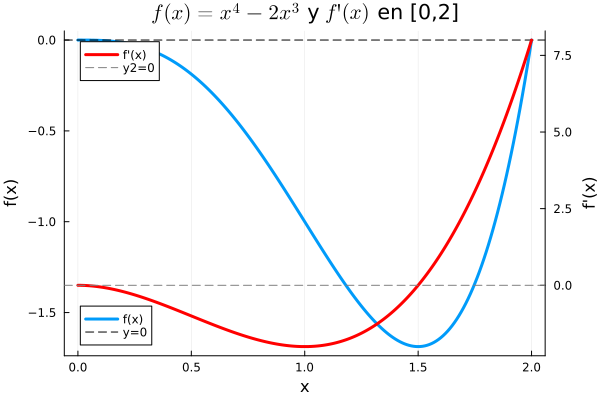

In [2]:
x = 0:0.01:2
f = x.^4 .- 2 .* x.^3
f_1der = 4 .* x.^3 .- 6 .* x.^2

# Primer eje (izquierdo)
p1 = plot(x, f,
          linewidth=3,
          title = raw"$f(x) = x^4 - 2x^3$ y $f'(x)$ en [0,2]",
          xlabel="x",
          ylabel="f(x)",
          label="f(x)",
          legend=:bottomleft)

hline!(p1, [0], linestyle=:dash, color=:black, label="y=0")

# Segundo eje (derecho)
p2 = twinx()

plot!(p2, x, f_1der,
      color=:red,
      linewidth=3,
      ylabel="f'(x)",
      label="f'(x)")

hline!(p2, [0], linestyle=:dash, color=:gray, label="y2=0")

La función f(x) es decreciente en el intervalo
(0,3/2) y creciente en (3/2,2). Esto coincide con el signo de la derivada f′(x)

- Cuando f′(x)<0, la función decrece.
- Cuando f′(x)>0, la función crece.

La función alcanza un mínimo local en x=3/2, donde f′(x)=0.

En x=0, aunque f′(0)=0, no hay máximo ni mínimo local en el intervalo considerado.

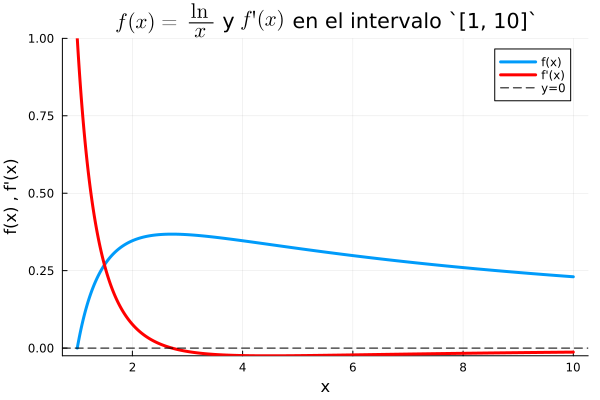

In [3]:
x = 1:0.01:10
f=log.(x)./x;
f_1der = (1 .- log.(x)) ./ x.^2;

# Límites globales
ymin = minimum(vcat(f, f_1der))
ymax = maximum(vcat(f, f_1der))

plot(x, f,
     linewidth=3,
     title = raw"$f(x) = \frac{\ln}{x}$ y $f'(x)$ en el intervalo `[1, 10]`",
     xlabel = "x",
     ylabel = "f(x) , f'(x)",
     label="f(x)",
     legend=:topright,
     ylims=(ymin, ymax))

plot!(x, f_1der,
      color=:red,
      linewidth=3,
      label="f'(x)",
      ylims=(ymin, ymax))

hline!([0], linestyle=:dash, color=:black, label="y=0")

La función f(x)= ln(⁡x) / x es creciente en el intervalo
(1,e) y decreciente en (e,∞)

Esto coincide con el signo de la derivada f′(x)

- Cuando f′(x)>0, la función crece.
- Cuando f′(x)<0, la función decrece.

La función alcanza un máximo local en  x=e, donde
f′(x)=0

En este caso no hay mínimo local en el intervalo considerado.

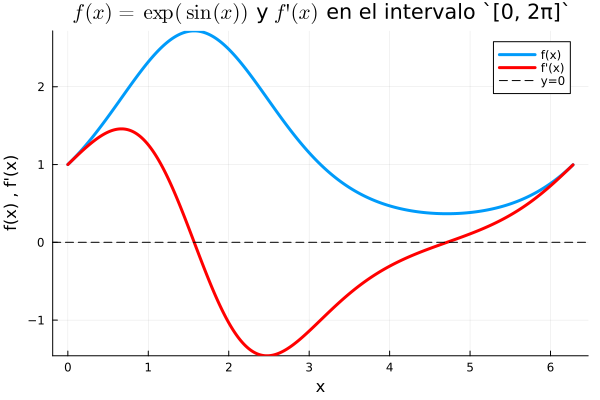

In [4]:
x = 0:0.01:2pi
f=exp.(sin.(x));
f_1der = exp.(sin.(x)) .* cos.(x);

# Límites globales
ymin = minimum(vcat(f, f_1der))
ymax = maximum(vcat(f, f_1der))

plot(x, f,
     linewidth=3,
     title = raw"$f(x) = \exp(\sin(x))$ y $f'(x)$ en el intervalo `[0, 2π]`",
     xlabel = "x",
     ylabel = "f(x) , f'(x)",
     label="f(x)",
     legend=:topright,
     ylims=(ymin, ymax))

plot!(x, f_1der,
      color=:red,
      linewidth=3,
      label="f'(x)",
      ylims=(ymin, ymax))

hline!([0], linestyle=:dash, color=:black, label="y=0")

La función f(x) = ln(⁡x) / x es creciente en el intervalo (1,e) y decreciente en (e,∞)

Esto coincide con el signo de la derivada f′(x) = 1 − ln(⁡x) / x^2.

- Cuando f′(x)>0 (es decir, cuando 1−ln⁡x > 0 ⇒ x<e, la función es creciente.

- Cuando f′(x)<0 (cuando x>e, la función es decreciente.

La función alcanza un máximo local en x=e, ya que: f′(e)=0

y la derivada cambia de positiva a negativa en ese punto.

En el intervalo considerado no se presenta ningún mínimo local.

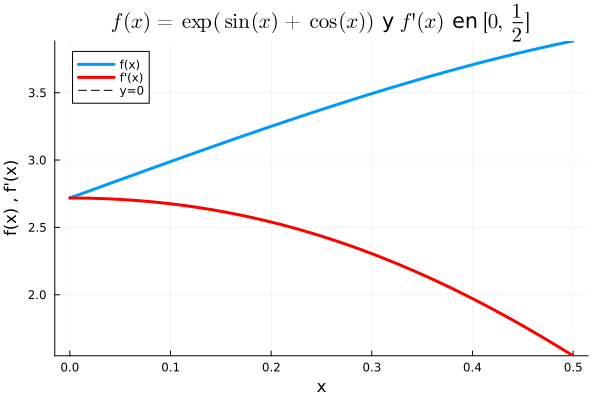

In [5]:
x = 0:0.01:0.5
f = exp.(sin.(x) .+ cos.(x));
f_1der = exp.(sin.(x) .+ cos.(x)) .* (cos.(x) .- sin.(x));

# Límites globales
ymin = minimum(vcat(f, f_1der))
ymax = maximum(vcat(f, f_1der))

plot(x, f,
     linewidth=3,
     title = raw"$f(x) = \exp(\sin(x)+\cos(x))$ y $f'(x)$ en $[0,\frac{1}{2}]$",
     xlabel = "x",
     ylabel = "f(x) , f'(x)",
     label="f(x)",
     legend=:topleft,
     ylims=(ymin, ymax))

plot!(x, f_1der,
      color=:red,
      linewidth=3,
      label="f'(x)",
      ylims=(ymin, ymax))

hline!([0], linestyle=:dash, color=:black, label="y=0")

La función en el intervalo solicitado es estrictamente creciente (0,1/2). Esto se debe a que su derivada:

f′(x)=exp(sinx+cosx)*(cosx−sinx)

es positiva en todo el intervalo, ya que sinx+cosx > 0 y
cos⁡x>sin⁡x para 0 < x < 1/2

Por lo tanto, en este intervalo no hay máximos ni mínimos locales.

###**Parte 2: La Confirmación Numérica - Encontrando los Puntos Críticos**

**Herramientas:** Julia y la librería `Plots.jl`.

Uso de Julia para encontrar con alta precisión los puntos donde el comportamiento de una función cambia

Para la función **$f(x) = x^4 - x^2$**:

1.  Grafique `f(x)` y su derivada `f'(x)` en un intervalo que muestre claramente su comportamiento (por ejemplo, `[-1.5, 1.5]`).
2.  A mano, sabemos que la derivada es $f'(x) = 4x^3 - 2x$. Para encontrar los puntos críticos, necesitamos resolver la ecuación $f'(x) = 0$.
3.  Use Julia para encontrar las raíces de la derivada numéricamente. Puede usar la librería `Roots.jl`:
    ```julia
    using Roots
    f_prime(x) = 4*x^3 - 2*x
    zeros = find_zeros(f_prime, -1.5, 1.5)
    println("Los puntos críticos encontrados numéricamente son: ", zeros)
    ```
4.  Verifique que los ceros encontrados numéricamente coincidan con la solución analítica que puede encontrar a mano ($x=0$, $x=\pm \frac{1}{\sqrt{2}}$).
5.  Escriba una conclusión final en Markdown: Basándose en los puntos críticos encontrados numéricamente y el signo de la derivada entre ellos, defina con precisión los intervalos (lo más grandes posible) donde $f(x)$ es estrictamente creciente y estrictamente decreciente. Compare este resultado con su inspección visual del gráfico.

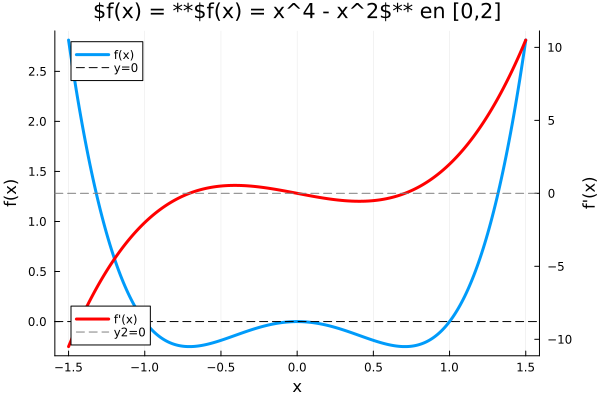

In [6]:
x = -1.5:0.01:1.5
f = x.^4 .-  x .^2
f_1der = 4 .* x.^3 .- 2 .* x

# Primer eje (izquierdo)
p1 = plot(x, f,
          linewidth=3,
          title = raw"$f(x) = **$f(x) = x^4 - x^2$** en [0,2]",
          xlabel="x",
          ylabel="f(x)",
          label="f(x)",
          legend=:topleft) # Cambiado de :centerleft a :topleft

hline!(p1, [0], linestyle=:dash, color=:black, label="y=0")

# Segundo eje (derecho)
p2 = twinx()

plot!(p2, x, f_1der,
      color=:red,
      linewidth=3,
      ylabel="f'(x)",
      label="f'(x)",
      legend=:bottomleft)

hline!(p2, [0], linestyle=:dash, color=:gray, label="y2=0")

In [7]:
import Pkg; Pkg.add("Roots")
using Roots
f_prime(x) = 4*x^3 - 2*x
zeros_f_prime = find_zeros(f_prime, -1.5, 1.5)
println("Los puntos críticos encontrados numéricamente son: ", zeros_f_prime)

# Verificación analítica
sol_analitica = [0, 1/sqrt(2), -1/sqrt(2)]
println("Los puntos críticos analíticos son: ", sort(sol_analitica))

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed CommonSolve ────── v0.2.6
   Installed CompositionsBase ─ v0.1.2
   Installed Accessors ──────── v0.1.43
   Installed Roots ──────────── v2.2.12
    Updating `~/.julia/environments/v1.11/Project.toml`
  [f2b01f46] + Roots v2.2.12
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [7d9f7c33] + Accessors v0.1.43
  [38540f10] + CommonSolve v0.2.6
  [a33af91c] + CompositionsBase v0.1.2
  [f2b01f46] + Roots v2.2.12
Precompiling project...
   3959.7 ms  ✓ CommonSolve
   3295.2 ms  ✓ CompositionsBase
    686.9 ms  ✓ CompositionsBase → CompositionsBaseInverseFunctionsExt
   3312.3 ms  ✓ Accessors
   2083.9 ms  ✓ Accessors → StructArraysExt
   2381.6 ms  ✓ Accessors → LinearAlgebraExt
   2799.5 ms  ✓ Accessors → TestExt
   2025.0 ms  ✓ Accessors → IntervalSetsExt
   1966.4 ms  ✓ Accessors → UnitfulExt
   1869.2 ms  ✓ Accessors → StaticArraysExt
   4448.6 ms  ✓ Roots
   1666.7 ms  ✓ 

Los puntos críticos encontrados numéricamente son: [-0.7071067811865475, 0.0, 0.7071067811865475]
Los puntos críticos analíticos son: [-0.7071067811865475, 0.0, 0.7071067811865475]


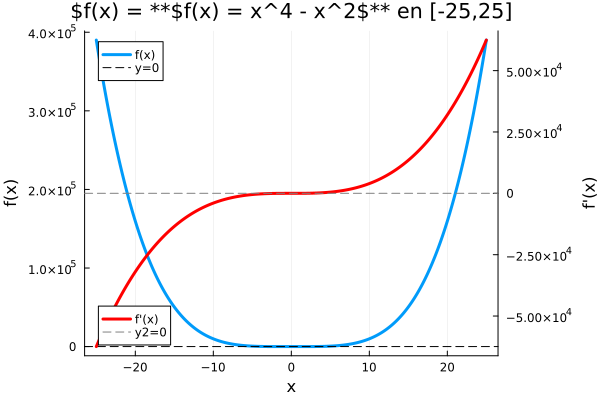

In [8]:
x = -25:0.01:25
f = x.^4 .-  x .^2
f_1der = 4 .* x.^3 .- 2 .* x

# Primer eje (izquierdo)
p1 = plot(x, f,
          linewidth=3,
          title = raw"$f(x) = **$f(x) = x^4 - x^2$** en [-25,25]",
          xlabel="x",
          ylabel="f(x)",
          label="f(x)",
          legend=:topleft)

hline!(p1, [0], linestyle=:dash, color=:black, label="y=0")

# Segundo eje (derecho)
p2 = twinx()

plot!(p2, x, f_1der,
      color=:red,
      linewidth=3,
      ylabel="f'(x)",
      label="f'(x)",
      legend=:bottomleft)

hline!(p2, [0], linestyle=:dash, color=:gray, label="y2=0")

####5. Conclusión final

$f(x)$ es estrictamente creciente en los intervalos (-1/$\sqrt{2}$ , 0) y (1/$\sqrt{2}$ , $\infty$)

$f(x)$ es estrictamente decreciente en los intervalos (-$\infty$ , -1/$\sqrt{2}$) y (0, 1/$\sqrt{2}$)

Esta deducción se confirma visualmente al verificar los valores que toma $f'(x)$ siendo mayor que cero cuando $f(x)$ es creciente y viceversa.

### **Parte 3: El Desafío - Analizando la "Derivada" de Datos Discretos**

Imagine que es un científico analizando los datos de un sensor de temperatura a lo largo de 24 horas. Los datos son discretos y tienen algo de "ruido", por lo que no tenemos una función suave para derivar analíticamente. En su lugar, vamos a **aproximar la tasa de cambio** entre cada par de puntos consecutivos.

**Los Datos:**
```julia
using Plots

# Datos de temperatura (horas, grados Celsius)
horas = 0:0.5:24
temperaturas = [15.1, 14.5, 14.2, 13.9, 13.5, 13.8, 14.1, 15.0, 16.2, 17.5, 18.9, 20.1, 21.5, 22.8, 23.9, 24.5, 25.1, 25.5, 25.3, 24.8, 24.1, 23.5, 22.8, 22.0, 21.1, 20.5, 19.8, 19.1, 18.5, 18.0, 17.5, 17.0, 16.5, 16.1, 15.8, 15.5, 15.3, 15.1, 14.9, 14.7, 14.5, 14.4, 14.3, 14.2, 14.1, 14.0, 13.9, 13.8, 13.7]
```

**Su Misión:**

1.  **Visualice los datos crudos:** Haga un gráfico de dispersión (`scatter`) de `temperaturas` vs `horas`. ¿Puede estimar visualmente cuándo la temperatura fue máxima?

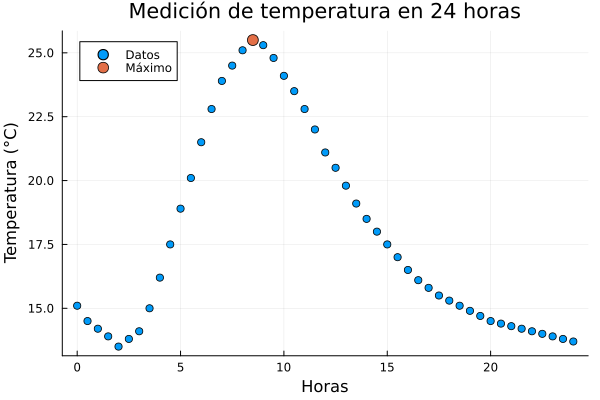

In [9]:
horas = 0:0.5:24
temperaturas = [15.1, 14.5, 14.2, 13.9, 13.5, 13.8, 14.1, 15.0, 16.2, 17.5, 18.9, 20.1, 21.5, 22.8, 23.9, 24.5, 25.1, 25.5, 25.3, 24.8, 24.1, 23.5, 22.8, 22.0, 21.1, 20.5, 19.8, 19.1, 18.5, 18.0, 17.5, 17.0, 16.5, 16.1, 15.8, 15.5, 15.3, 15.1, 14.9, 14.7, 14.5, 14.4, 14.3, 14.2, 14.1, 14.0, 13.9, 13.8, 13.7]

scatter(horas, temperaturas,
        markersize=4,
        title="Medición de temperatura en 24 horas",
        xlabel="Horas",
        ylabel="Temperatura (°C)",
        label="Datos",
        legend=:topleft)

imax = argmax(temperaturas)

scatter!( [horas[imax]], [temperaturas[imax]],
          markersize=6,
          label="Máximo")

Visulamente no se puede determinar la hora precisa donde alcanza la temperatura mas alta, sin embargo mejorando la escala o realizando un cálculo a través de Julia se puede estimar con exactitud

2.  **Calcule la tasa de cambio aproximada:** La "derivada" en un punto puede ser aproximada por la pendiente de la recta que une ese punto con el siguiente. Esto se conoce como **diferencia finita hacia adelante**: $v_i \approx \frac{T_{i+1} - T_i}{h_{i+1} - h_i}$, donde `T` es la temperatura y `h` es la hora.


In [10]:
    # Calcular la tasa de cambio aproximada (en °C por hora)
    tasas_de_cambio = []
    # Iteramos hasta el penúltimo elemento, ya que cada cálculo usa el punto i y el i+1
    for i in 1:(length(horas)-1)
        delta_temp = temperaturas[i+1] - temperaturas[i]
        delta_hora = horas[i+1] - horas[i]
        tasa = delta_temp / delta_hora
        push!(tasas_de_cambio, tasa)
    end
    # Los puntos de tiempo para las tasas de cambio corresponden al inicio de cada intervalo
    horas_tasa = horas[1:end-1]

0.0:0.5:23.5

3.  **Visualice la tasa de cambio:** Genere un gráfico de `tasas_de_cambio` vs `horas_tasa`. Use un gráfico de barras (`bar`) o de líneas (`plot`). Añada una línea horizontal en `y=0` para ver claramente cuándo la tasa es positiva (la temperatura sube) y cuándo es negativa (la temperatura baja).

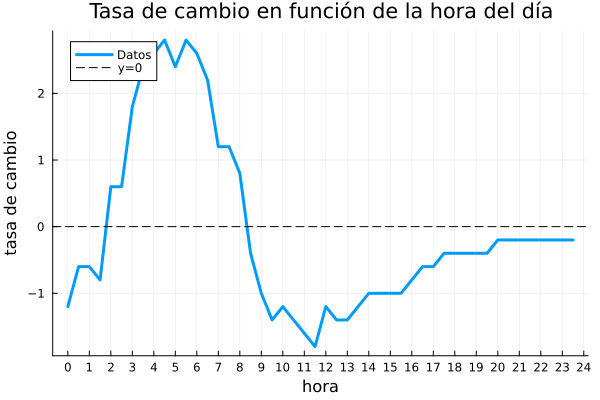

In [11]:
plot(horas_tasa, tasas_de_cambio,
          linewidth=3,
          title = "Tasa de cambio en función de la hora del día",
          xlabel="hora",
          ylabel="tasa de cambio",
          label="Datos",
          legend=:topleft,
          xticks=0:1:24)

hline!([0], linestyle=:dash, color=:black, label="y=0")

4.  **Escriba sus conclusiones científicas:**

    *   ¿En qué intervalo de tiempo la tasa de cambio pasa de ser positiva a ser negativa? ¿Qué significa esto en el contexto del problema?

    La tasa de cambio es negativa en el intervalo de horas (0 , 2) y (8 , 24); por otro lado, su valor es positivo entre (2 , 8). Este comportamiento se traduce en que dependiendo del valor de la tasa de cambio (sea positivo o negativo) los valores de temperatura tienen crecimiento o reducción en función del tiempo transcurrido.
    
    *   Según su análisis de la tasa de cambio, ¿alrededor de qué hora del día se alcanzó la temperatura máxima? Compare esta estimación con su inspección visual del primer gráfico.

    Donde se alcanza la máxima temperatura se deduce a partir de la razón de cambio, donde pasa de ser positiva (incremento de valores de temperatura) a negativa (reducción de valores). De manera similar se deduce la hora de mínima de temperatura con un patron contrario al mencionado anteriormente.

    *   ¿Cuáles fueron los intervalos de tiempo durante los cuales la temperatura estaba, en general, subiendo? ¿Y bajando?
    Los intervalos de tiempo en que sube y baja la temperatura coinciden con los valores positivos o negativos de la tasa de cambio, es decir, en el intervalo de horas (0 , 2) y (8 , 24) donde la tasa de cambio es negativa la temperatura se encontraba en disminución; por otro lado, cuando el valor de la tasa de cambio era positivo entre (2 , 8) la temperatura estaba subiendo.

# Uso de Inteligencia Artificial

Para realizar este trabajo utilicé inteligencia artificial (ChatGPT) como una herramienta de apoyo. Principalmente la usé para confirmar que la redacción del código estuviera correcto y buscar mejoras, aprendiendo nuevos comandos, así como para verificar los cálculos y procedimientos que iba desarrollando.

También me ayudó a revisar detalles del código en Julia, como la forma correcta de hacer las gráficas, ajustar los ejes y asegurar que la interpretación de los resultados fuera coherente con las instrucicones dadas.

En todo momento hice las verificaciones personalmente y me aseguré de entender cada paso antes de incluirlo en el desarrollo final. La inteligencia artificial fue un apoyo para confirmar y revisar, no para reemplazar el análisis propio.